In [2]:
import pandas as pd

# ถ้าอัปโหลดเข้า Session โดยตรง
df = pd.read_csv('AirQuality_Final.csv')

# หรือถ้าเป็นไฟล์ Excel
# df = pd.read_excel('ชื่อไฟล์ของคุณ.xlsx')

# ดูข้อมูล 5 แถวแรก
df.head()

,Year,Month,Province,Total_Population,Total_Vehicles,New_Factories,Rainfall,PM2.5
0,2020,Jan,กรุงเทพมหานคร,5588222,10971799.0,64,9.766667,40.583333
1,2020,Jan,นนทบุรี,1276745,189955.0,35,0.000000,42.000000
2,2020,Jan,ปทุมธานี,1176412,175071.0,77,0.000000,41.000000
3,2020,Jan,สมุทรปราการ,1351479,162670.0,205,0.000000,40.600000
4,2020,Jan,สมุทรสาคร,586199,244894.0,288,0.000000,44.000000


In [3]:
df.info()        # ดูประเภทข้อมูลและค่าว่าง
df.describe()    # ดูค่าสถิติพื้นฐาน (Mean, Max, Min)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4620 entries, 0 to 4619
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              4620 non-null   int64  
 1   Month             4620 non-null   object 
 2   Province          4620 non-null   object 
 3   Total_Population  4620 non-null   int64  
 4   Total_Vehicles    4620 non-null   float64
 5   New_Factories     4620 non-null   int64  
 6   Rainfall          4620 non-null   float64
 7   PM2.5             4620 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 288.9+ KB


,Year,Total_Population,Total_Vehicles,New_Factories,Rainfall,PM2.5
count,4620.000000,4.620000e+03,4.620000e+03,4620.000000,4620.000000,4620.000000
mean,2022.000000,8.583578e+05,5.588715e+05,30.615584,96.499448,23.062980
std,1.414367,7.156924e+05,1.305377e+06,44.309323,157.601449,15.044196
min,2020.000000,1.867840e+05,7.289400e+04,0.000000,0.000000,4.000000
25%,2021.000000,4.727220e+05,2.237180e+05,8.000000,0.000000,11.800000
50%,2022.000000,6.841400e+05,3.257580e+05,16.000000,19.883333,18.666667
75%,2023.000000,1.075788e+06,5.106390e+05,32.000000,150.800000,31.000000
max,2024.000000,5.588222e+06,1.221990e+07,288.000000,1662.000000,146.000000


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. โหลดข้อมูล
df = pd.read_csv('AirQuality_Final.csv')

# 2. เตรียมข้อมูล (Preprocessing)
# แปลงชื่อจังหวัดและเดือนเป็นตัวเลขเพื่อให้โมเดลคำนวณได้
le = LabelEncoder()
df['Province_Encoded'] = le.fit_transform(df['Province'])

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df['Month_Num'] = df['Month'].map(month_map)

# เลือก Feature ที่จะใช้เทรน
features = ['Year', 'Month_Num', 'Province_Encoded', 'Total_Population', 'Total_Vehicles', 'New_Factories', 'Rainfall']
X = df[features]
y = df['PM2.5']

# 3. แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. สร้างและเทรนโมเดล
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. วัดผล
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} µg/m³")

# 6. ดูว่าปัจจัยไหนสำคัญที่สุด
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:")
print(importance)

R-squared Score: 0.87
Mean Absolute Error: 2.99 µg/m³

Feature Importance:
Month_Num           0.604626
Province_Encoded    0.106099
Total_Vehicles      0.083188
Total_Population    0.077682
Rainfall            0.056488
New_Factories       0.051166
Year                0.020752
dtype: float64


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. โหลดข้อมูล
df = pd.read_csv('AirQuality_Final.csv')

# 2. จัดการเรื่องเวลา (Cyclical Month)
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)

# 3. [Advanced] สร้างค่าเฉลี่ยฝุ่นแยกตามจังหวัดและเดือน (Historical Baseline)
# ตัวแปรนี้จะบอกโมเดลว่า "โดยปกติแล้ว จังหวัด A ในเดือน B มีฝุ่นประมาณเท่าไหร่"
historical_avg = df.groupby(['Province', 'Month_Num'])['PM2.5'].mean().reset_index()
historical_avg.columns = ['Province', 'Month_Num', 'PM2.5_Hist_Avg']
df = df.merge(historical_avg, on=['Province', 'Month_Num'], how='left')

# 4. ทำ Lag Feature 1 เดือน (เพื่อดูแนวโน้มล่าสุด)
df = df.sort_values(by=['Province', 'Year', 'Month_Num'])
df['PM2.5_Lag1'] = df.groupby('Province')['PM2.5'].shift(1)

# 5. [Important] ลบค่าว่างที่เกิดจาก Lag
df_clean = df.dropna().copy()

# 6. แปลงชื่อจังหวัดเป็นตัวเลข
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['Province_Encoded'] = le.fit_transform(df_clean['Province'])

# 7. เลือกฟีเจอร์ที่ผ่านการคัดเลือกแล้ว (Feature Selection)
# สังเกตว่าเราเพิ่ม PM2.5_Hist_Avg เข้าไปด้วย
features = ['Year', 'Month_Num', 'Province_Encoded', 'Total_Population',
            'Total_Vehicles', 'New_Factories', 'Rainfall', 'PM2.5_Lag1', 'PM2.5_Hist_Avg']

X = df_clean[features]
y = df_clean['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. ใช้ RandomForest พร้อมปรับจูนเบื้องต้น
# เพิ่ม n_estimators เป็น 500 และใช้ max_features='sqrt' เพื่อลด Overfitting
model = RandomForestRegressor(n_estimators=500, max_depth=25, random_state=42)
model.fit(X_train, y_train)

# 9. วัดผล
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

R-squared Score: 0.9117


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. เตรียมข้อมูลและ Feature Engineering (ใช้ชุดตัวแปรเดิมทั้งหมด)
df = pd.read_csv('AirQuality_Final.csv')
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)

# สร้าง Historical Baseline และ Lag เพื่อความแม่นยำ
historical_avg = df.groupby(['Province', 'Month_Num'])['PM2.5'].mean().reset_index()
historical_avg.columns = ['Province', 'Month_Num', 'PM2.5_Hist_Avg']
df = df.merge(historical_avg, on=['Province', 'Month_Num'], how='left')

df = df.sort_values(by=['Province', 'Year', 'Month_Num'])
df['PM2.5_Lag1'] = df.groupby('Province')['PM2.5'].shift(1)

# ทำความสะอาดข้อมูลและ Encoding
df_clean = df.dropna().copy()
le = LabelEncoder()
df_clean['Province_Encoded'] = le.fit_transform(df_clean['Province'])

# 2. กำหนดตัวแปรและแบ่งข้อมูล
features = ['Year', 'Month_Num', 'Province_Encoded', 'Total_Population',
            'Total_Vehicles', 'New_Factories', 'Rainfall', 'PM2.5_Lag1', 'PM2.5_Hist_Avg']
X = df_clean[features]
y = df_clean['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. สร้าง List ของ 3 โมเดลที่ต้องการเปรียบเทียบ
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42)
}

# 4. เทรนและเก็บผลลัพธ์
comparison_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    comparison_results.append({"Model": name, "R2 Score": r2, "MAE": mae})

# 5. แสดงตารางเปรียบเทียบ
results_df = pd.DataFrame(comparison_results)
print(results_df.sort_values(by="R2 Score", ascending=False))

               Model  R2 Score       MAE
2      Random Forest  0.911355  2.491910
0  Linear Regression  0.907465  2.708156
1      Decision Tree  0.838861  3.314382


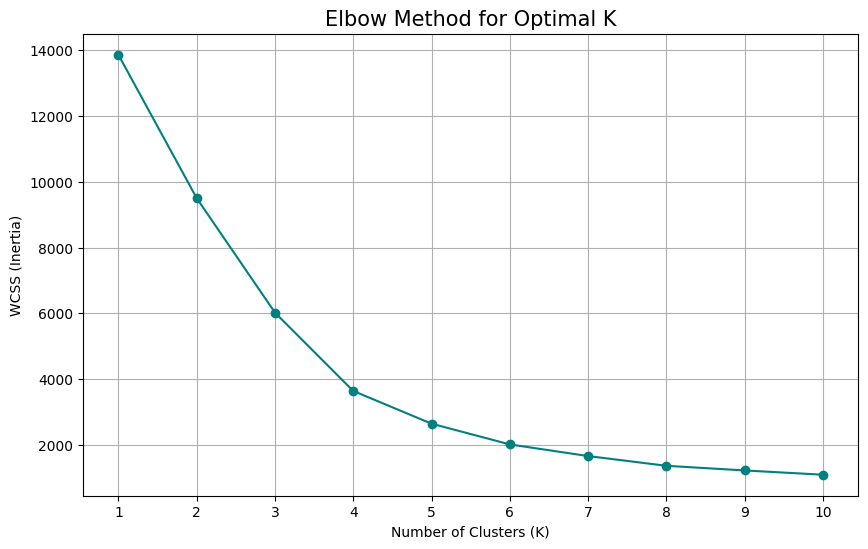

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. โหลดและเตรียมข้อมูล
df = pd.read_csv('AirQuality_Final.csv')
features = ['PM2.5', 'Rainfall', 'Total_Vehicles']
X = df[features]

# 2. ทำ Scaling ข้อมูล
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. คำนวณค่า WCSS (Inertia) สำหรับ K ตั้งแต่ 1 ถึง 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. พล็อตกราฟ Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='teal')
plt.title('Elbow Method for Optimal K', fontsize=15)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

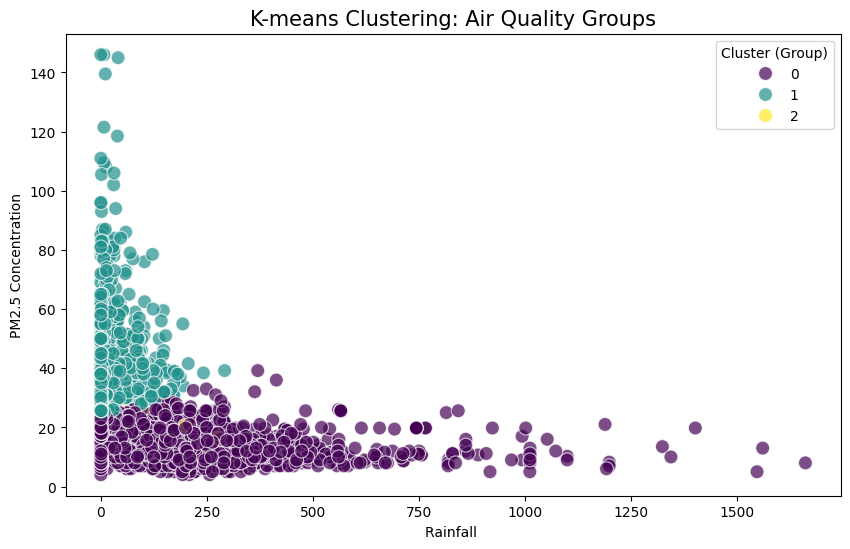

--- สรุปค่าเฉลี่ยของแต่ละคลัสเตอร์ ---
             PM2.5    Rainfall  Total_Vehicles
Cluster                                       
0        14.258126  138.678471    4.223194e+05
1        39.248723   18.181118    3.972393e+05
2        23.733421  114.197917    1.160772e+07


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv('AirQuality_Final.csv')

# 2. เลือกฟีเจอร์ที่ต้องการนำมาจัดกลุ่ม (ควรใช้ข้อมูลตัวเลขที่มีความสัมพันธ์กัน)
# ในที่นี้เราใช้ PM2.5, Rainfall และ Total_Vehicles
features = ['PM2.5', 'Rainfall', 'Total_Vehicles']
X = df[features]

# 3. การทำ Scaling (สำคัญมากสำหรับ K-means เพราะถ้าหน่วยไม่เท่ากัน โมเดลจะเพี้ยน)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. สั่งรัน K-means (กำหนด K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. พล็อตกราฟแยกสีตามคลัสเตอร์
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall', y='PM2.5', hue='Cluster',
                palette='viridis', s=100, alpha=0.7, edgecolor='w')

plt.title('K-means Clustering: Air Quality Groups', fontsize=15)
plt.xlabel('Rainfall ')
plt.ylabel('PM2.5 Concentration')
plt.legend(title='Cluster (Group)')
plt.show()

# 6. แสดงค่าเฉลี่ยของแต่ละกลุ่มเพื่อนำไปวิเคราะห์ต่อในรายงาน
print("--- สรุปค่าเฉลี่ยของแต่ละคลัสเตอร์ ---")
print(df.groupby('Cluster')[features].mean())

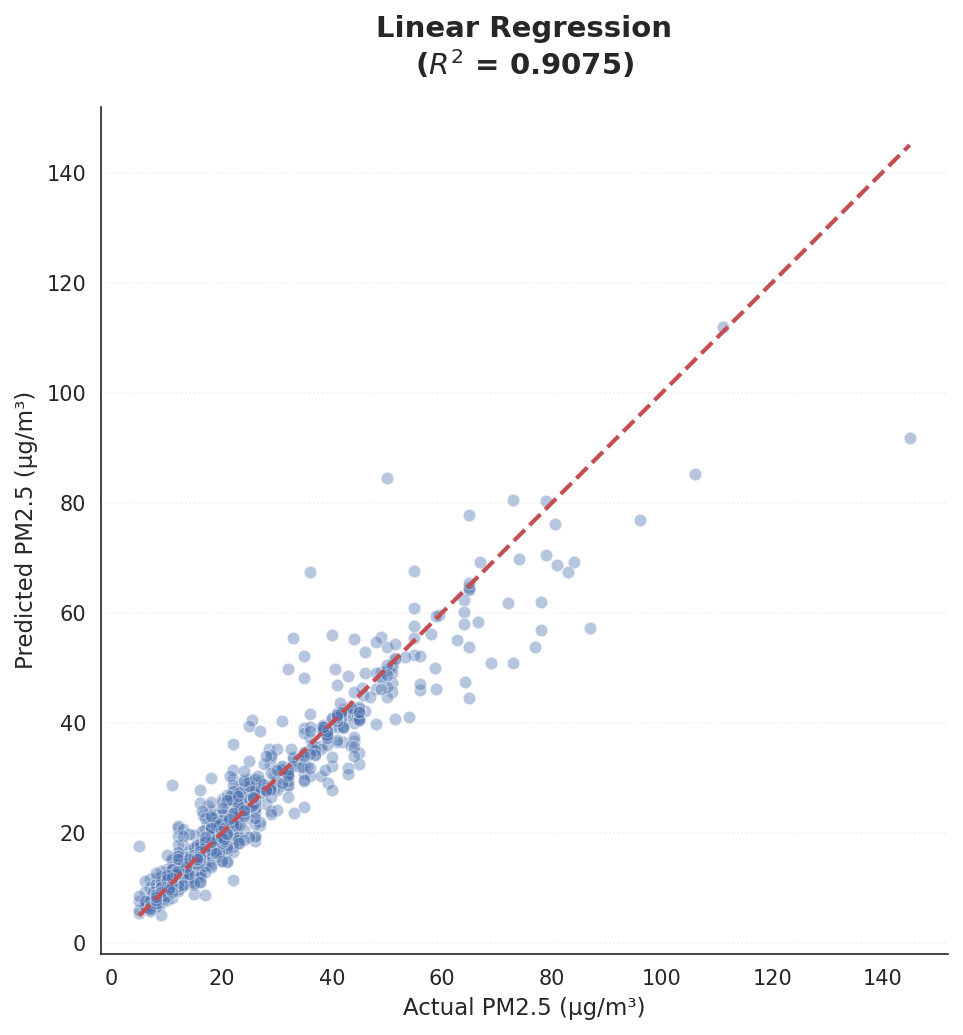

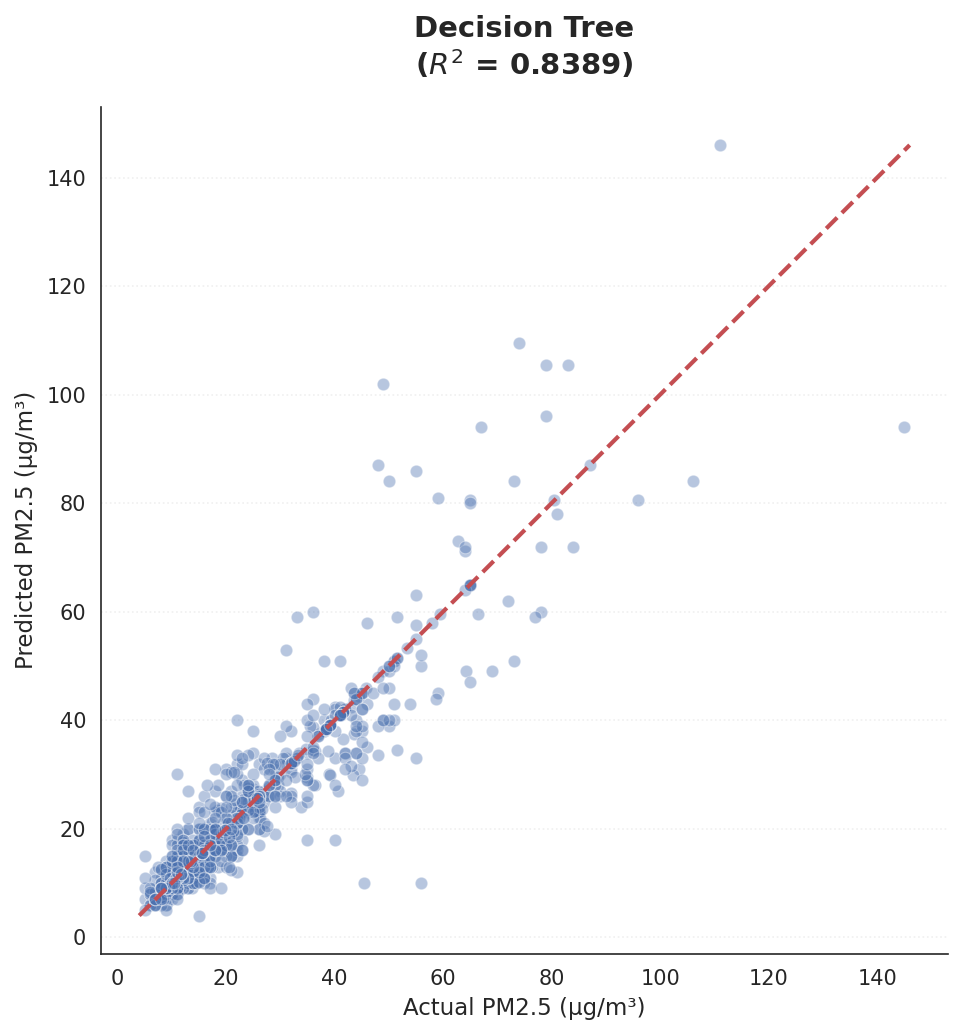

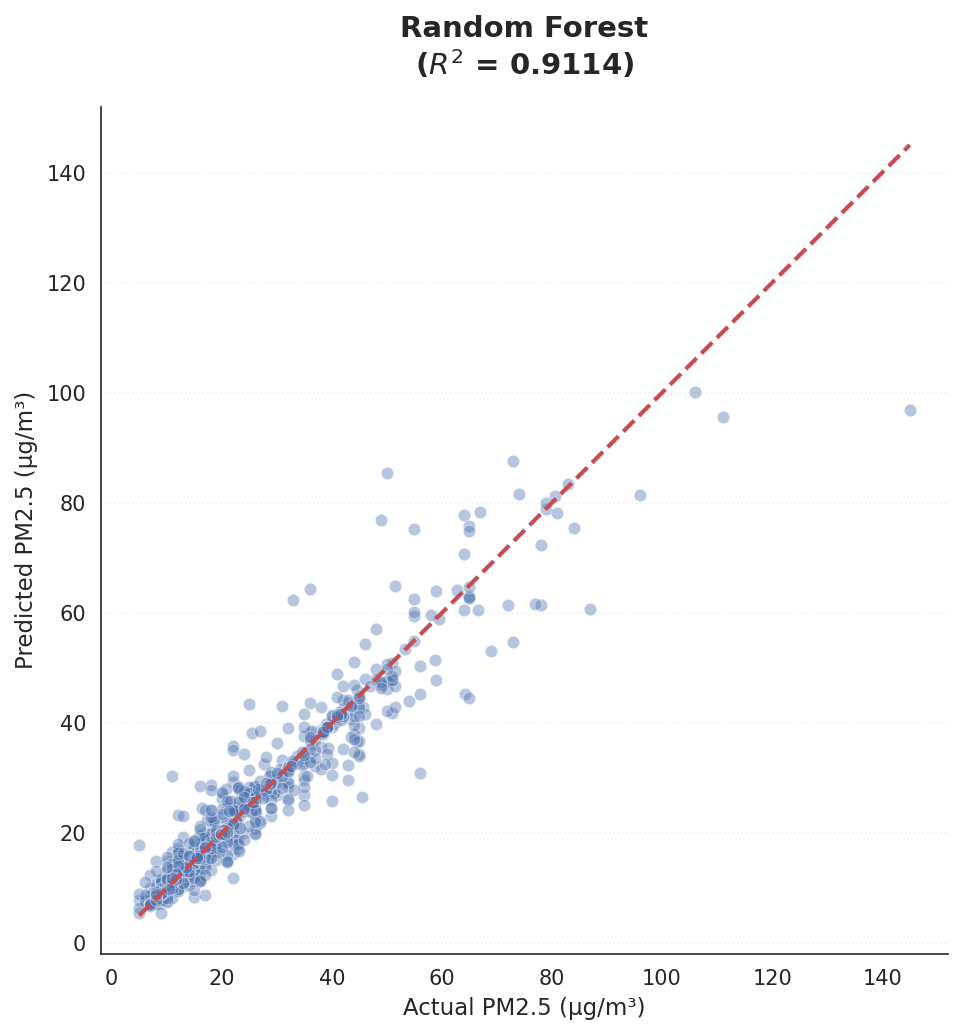

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. ตั้งค่าพื้นฐานแบบ Minimal
sns.set_style("white")
point_color = '#4C72B0' # สีน้ำเงินหม่น
line_color = '#C44E52'  # สีแดงอิฐ

# 2. วนลูปเพื่อสร้างรูปแยกกัน (แยกเป็น 3 Figure)
model_names = list(models.keys())

for name in model_names:
    # --- สร้างรูปใหม่ทุกครั้งที่วนลูป ---
    plt.figure(figsize=(7, 7), dpi=150)

    model = models[name]
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    # วาดจุดข้อมูล
    plt.scatter(y_test, y_pred, color=point_color, alpha=0.4, edgecolors='w', linewidth=0.5)

    # วาดเส้น Perfect Prediction
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color=line_color, linestyle='--', lw=2)

    # ตกแต่งหัวข้อและป้ายกำกับ
    plt.title(f'{name}\n($R^2$ = {r2:.4f})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Actual PM2.5 (µg/m³)', fontsize=11)
    plt.ylabel('Predicted PM2.5 (µg/m³)', fontsize=11)

    # ปรับแต่งความคลีน
    plt.gca().set_aspect('equal') # ทำให้กราฟเป็นสี่เหลี่ยมจัตุรัส
    sns.despine()                 # ลบกรอบบนและขวา
    plt.grid(axis='y', linestyle=':', alpha=0.3) # เพิ่มเส้น Grid จางๆ

    plt.tight_layout()
    # plt.savefig(f'prediction_{name}.png')
    plt.show()

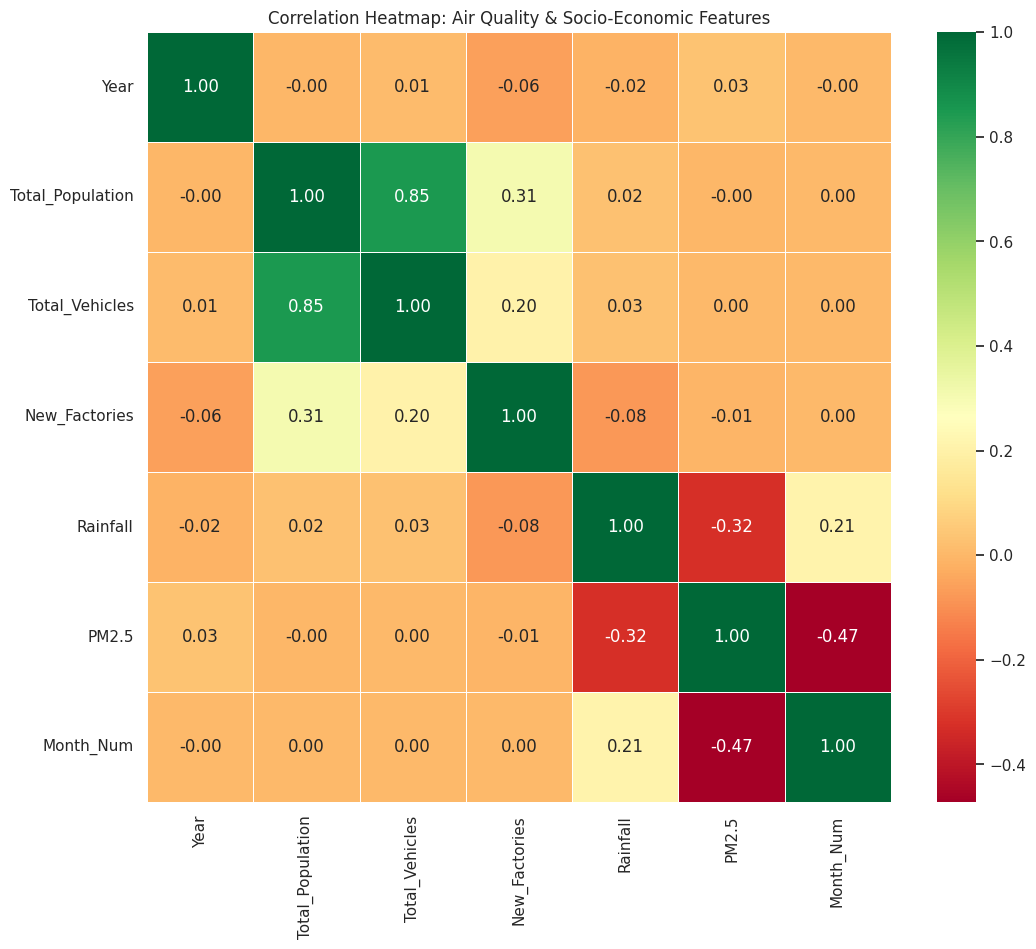

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. โหลดข้อมูล
df = pd.read_csv('AirQuality_Final.csv')

# 2. ทำ Feature Engineering เล็กน้อย (แปลงเดือนเป็นตัวเลขเพื่อให้คำนวณ Correlation ได้)
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['Month_Num'] = df['Month'].map(month_map)

# 3. เลือกเฉพาะ Column ที่เป็นตัวเลข
numeric_df = df.select_dtypes(include=[np.number])

# 4. คำนวณค่า Correlation Matrix
corr_matrix = numeric_df.corr()

# 5. สร้าง Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap: Air Quality & Socio-Economic Features')
plt.show()

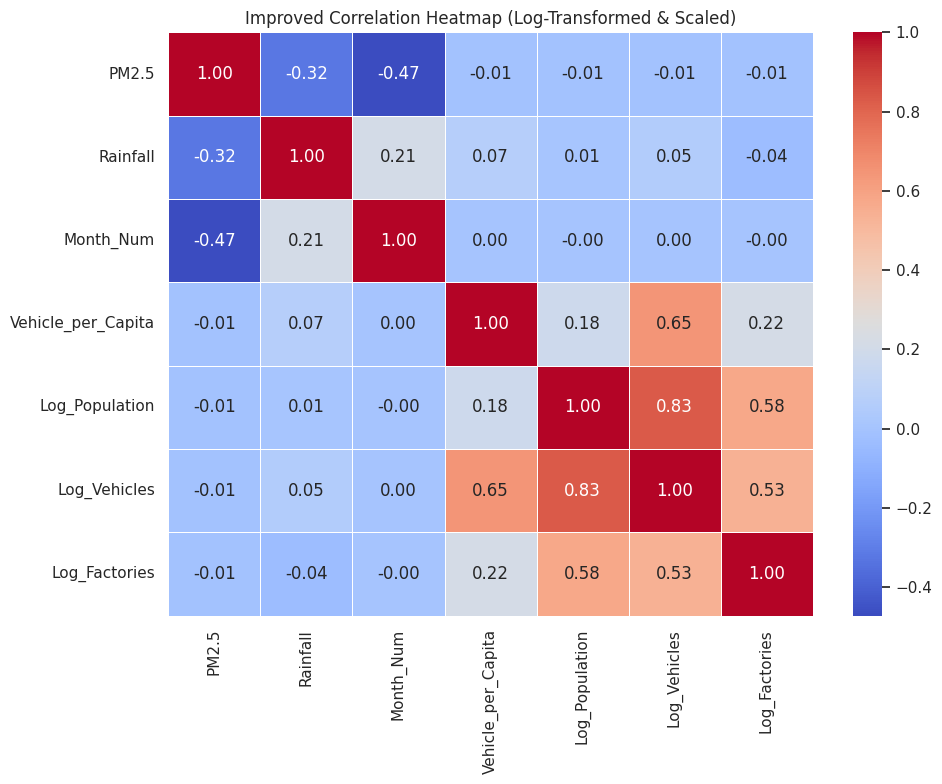

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. โหลดข้อมูล
df = pd.read_csv('AirQuality_Final.csv')

# 2. Feature Engineering & Transformation
# แปลงเดือนเป็นตัวเลข
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)

# สร้าง Feature ใหม่: สัดส่วนรถยนต์ต่อประชากร
df['Vehicle_per_Capita'] = df['Total_Vehicles'] / df['Total_Population']

# ใช้ Log Transformation เพื่อลดความเบ้ของข้อมูลประชากรและรถยนต์
df['Log_Population'] = np.log1p(df['Total_Population'])
df['Log_Vehicles'] = np.log1p(df['Total_Vehicles'])
df['Log_Factories'] = np.log1p(df['New_Factories'])

# 3. เลือก Feature ที่จะนำมาดูความสัมพันธ์
features = ['PM2.5', 'Rainfall', 'Month_Num', 'Vehicle_per_Capita',
            'Log_Population', 'Log_Vehicles', 'Log_Factories']
df_corr = df[features]

# 4. ทำ Standardization (ปรับสเกลข้อมูล)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_corr), columns=features)

# 5. คำนวณ Correlation และสร้าง Heatmap
plt.figure(figsize=(10, 8))
# ใช้สเปกตรัมสี RdYlGn เพื่อให้เห็นบวก/ลบ ชัดเจน
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Improved Correlation Heatmap (Log-Transformed & Scaled)')
plt.tight_layout()
plt.show()

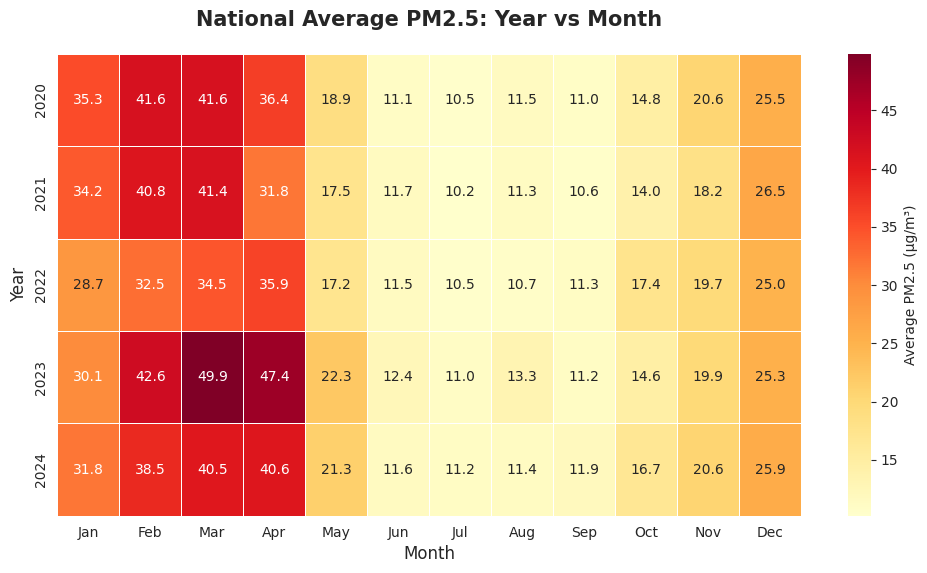

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูล Pivot Table (Year vs Month)
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
pivot_year_month = df.pivot_table(index='Year', columns='Month_Num', values='PM2.5', aggfunc='mean')
pivot_year_month.columns = [month_map[col] for col in pivot_year_month.columns]

# 2. พล็อตกราฟสไตล์คลีน
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_year_month, cmap='YlOrRd', annot=True, fmt=".1f",
            linewidths=.5, cbar_kws={'label': 'Average PM2.5 (µg/m³)'})

plt.title('National Average PM2.5: Year vs Month', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.show()